============================================================
PHASE 06 — APPLIED REPRESENTATION ANALYSIS
STEP 03 — EMBEDDING NEIGHBORHOOD ANALYSIS
============================================================

Repository Philosophy:

Tensor intuition first.
Representation systems second.
Architecture complexity later.

------------------------------------------------------------
CENTRAL QUESTION OF THIS STEP
------------------------------------------------------------

How does semantic similarity become spatial proximity?

Embedding systems organize concepts into:

    geometric neighborhoods

Nearby vectors often correspond to:

    semantically related concepts

1. To dog is wagging his tail.
2. The cat is watching the dog carefully.
3. The man is sipping tea.

The dog and the cat are semantically related.
But man id different here.

This step investigates:

    • nearest-neighbor structure
    • semantic clustering
    • local geometry
    • similarity metrics
    • neighborhood topology

using REAL pretrained embedding systems.

============================================================



============================================================
1. CONCEPTUAL INTRODUCTION
============================================================

CONCEPTUAL FOUNDATION
---------------------

Embedding systems transform concepts into vectors:

    cat      -> vector
    dog      -> vector
    tiger    -> vector

But embeddings are not randomly scattered.

Instead:

    semantically related concepts
    often occupy nearby geometric regions.

------------------------------------------------------------
SEMANTIC NEIGHBORHOODS
------------------------------------------------------------

Imagine semantic space as a landscape.

Nearby regions may contain:

    • animals
    • emotions
    • scientific concepts
    • technologies
    • political ideas

Each concept exists inside:

    a semantic neighborhood.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Semantic meaning becomes:

    spatial organization.

This is foundational to:

    • semantic search
    • retrieval systems
    • recommendation systems
    • RAG pipelines
    • vector databases

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

If similar meanings become nearby vectors,

then:

    what kind of geometry does language create?




============================================================
2. REPRESENTATION HYPOTHESIS
============================================================

REPRESENTATION HYPOTHESIS
-------------------------

Hypothesis:

    semantically related concepts
    should form local neighborhoods
    in embedding space.

Expected observations:

    cat      near dog
    physics  near chemistry
    king     near queen
    software near computer

------------------------------------------------------------
LOCAL GEOMETRY
------------------------------------------------------------

Instead of studying:

    entire semantic space

we now investigate:

    local semantic structure.

------------------------------------------------------------
IMPORTANT QUESTION
------------------------------------------------------------

How does the model decide:

    which concepts become neighbors?

Through:

    • co-occurrence statistics?
    • contextual similarity?
    • latent semantic structure?

------------------------------------------------------------
THINK DEEPLY
------------------------------------------------------------

Is meaning itself:

    a neighborhood structure?




============================================================
3. LOAD REAL EMBEDDING SYSTEM
============================================================

We now load a REAL pretrained embedding system.

------------------------------------------------------------
MODEL
------------------------------------------------------------

We use:

    all-MiniLM-L6-v2

This model maps text into:

    384-dimensional embedding vectors.

------------------------------------------------------------
GLOSSARY OF FUNCTIONS
------------------------------------------------------------

SentenceTransformer(...)
    Loads pretrained embedding system.

model.encode(...)
    Converts text into embeddings.

cos_sim(...)
    Computes cosine similarity.

torch.topk(...)
    Finds highest similarity values.

PCA(...)
    Reduces dimensionality for visualization.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

The model was not manually programmed
with semantic rules.

Instead:

    semantic geometry emerged through training.




In [1]:

from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

import torch
import numpy as np

# Load pretrained embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding system loaded successfully.")



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding system loaded successfully.


============================================================
4. EXTRACT EMBEDDINGS
============================================================

We now transform concepts into geometry.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Each embedding becomes:

    a point in semantic space.

Similar meanings may occupy:

    nearby regions.

------------------------------------------------------------
VOCABULARY DESIGN
------------------------------------------------------------

We intentionally include:

    • animals
    • royalty
    • emotions
    • science
    • technology

to observe:

    neighborhood formation.

------------------------------------------------------------
QUESTION
------------------------------------------------------------

Will semantic categories naturally cluster?




In [2]:

concepts = [
    "cat",
    "dog",
    "lion",
    "tiger",
    "wolf",
    "king",
    "queen",
    "prince",
    "princess",
    "computer",
    "software",
    "programming",
    "physics",
    "chemistry",
    "biology",
    "happy",
    "sad",
    "angry",
    "joy",
    "fear"
]

# Generate embeddings
embeddings = model.encode(
    concepts,
    convert_to_tensor=True
)

print("Embedding tensor shape:")
print(embeddings.shape)



Embedding tensor shape:
torch.Size([20, 384])


In [3]:

# Create embedding lookup dictionary

embedding_lookup = {
    concept: embeddings[i]
    for i, concept in enumerate(concepts)
}

print("Embedding lookup table created.")



Embedding lookup table created.


============================================================
5. SEMANTIC SIMILARITY ANALYSIS
============================================================

CORE IDEA
---------

We now compute:

    pairwise semantic similarity.

------------------------------------------------------------
COSINE SIMILARITY
------------------------------------------------------------

We use cosine similarity because:

    semantic direction often matters more
    than vector magnitude.

------------------------------------------------------------
MATHEMATICAL FORMULATION
------------------------------------------------------------

Cosine similarity:





where:

    x · y      = dot product
    ||x||      = vector magnitude
    θ          = angle between vectors

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

Values:

     1.0  -> highly similar
     0.0  -> unrelated
    -1.0  -> opposite direction

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Nearby vectors often imply:

    shared semantic structure.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Why does angular similarity correlate
with semantic similarity?




In [4]:

# Compute pairwise similarity matrix

similarity_matrix = cos_sim(
    embeddings,
    embeddings
)

print("Similarity matrix shape:")
print(similarity_matrix.shape)



Similarity matrix shape:
torch.Size([20, 20])


In [5]:

print("\nPAIRWISE SEMANTIC SIMILARITIES\n")

for i, concept_a in enumerate(concepts):

    for j, concept_b in enumerate(concepts):

        if i < j:

            similarity = similarity_matrix[i][j].item()

            print(
                f"{concept_a:12s} <-> "
                f"{concept_b:12s} : "
                f"{similarity:.4f}"
            )




PAIRWISE SEMANTIC SIMILARITIES

cat          <-> dog          : 0.6606
cat          <-> lion         : 0.5257
cat          <-> tiger        : 0.5453
cat          <-> wolf         : 0.4293
cat          <-> king         : 0.3610
cat          <-> queen        : 0.3265
cat          <-> prince       : 0.3601
cat          <-> princess     : 0.3394
cat          <-> computer     : 0.4089
cat          <-> software     : 0.2839
cat          <-> programming  : 0.3311
cat          <-> physics      : 0.2757
cat          <-> chemistry    : 0.2954
cat          <-> biology      : 0.3674
cat          <-> happy        : 0.2856
cat          <-> sad          : 0.1971
cat          <-> angry        : 0.3521
cat          <-> joy          : 0.3044
cat          <-> fear         : 0.3168
dog          <-> lion         : 0.4909
dog          <-> tiger        : 0.5121
dog          <-> wolf         : 0.5024
dog          <-> king         : 0.3644
dog          <-> queen        : 0.3113
dog          <-> prince       :

============================================================
6. NEAREST-NEIGHBOR ANALYSIS
============================================================

We now investigate:

    local semantic neighborhoods.

------------------------------------------------------------
CORE QUESTION
------------------------------------------------------------

Given a concept:

    which other concepts occupy nearby regions?

------------------------------------------------------------
NEAREST-NEIGHBOR SEARCH
------------------------------------------------------------

This is foundational to:

    • semantic search
    • vector retrieval
    • recommendation systems
    • retrieval-augmented generation

------------------------------------------------------------
GEOMETRIC INTERPRETATION
------------------------------------------------------------

Neighbor retrieval means:

    searching semantic space

for nearby geometric states.

------------------------------------------------------------
IMPORTANT QUESTION
------------------------------------------------------------

Does intelligence partially emerge through:

    neighborhood traversal?




In [6]:

def find_nearest_neighbors(
    query_word,
    embedding_lookup,
    top_k=5
):
    """
    Find nearest semantic neighbors.

    PARAMETERS
    ----------
    query_word:
        Concept to investigate.

    embedding_lookup:
        Dictionary of embeddings.

    top_k:
        Number of neighbors to return.

    RETURNS
    -------
    Sorted similarity neighbors.

    --------------------------------------------------------
    IMPORTANT IDEA
    --------------------------------------------------------

    We are effectively asking:

        Which regions of semantic space
        surround this concept?
    """

    query_embedding = embedding_lookup[query_word]

    similarities = []

    for word, embedding in embedding_lookup.items():

        similarity = cos_sim(
            query_embedding,
            embedding
        ).item()

        similarities.append((word, similarity))

    similarities = sorted(
        similarities,
        key=lambda x: x[1],
        reverse=True
    )

    return similarities[:top_k]



In [7]:

query_words = [
    "cat",
    "king",
    "physics",
    "happy"
]

for query in query_words:

    print("\n" + "=" * 60)
    print(f"NEAREST NEIGHBORS FOR: {query}")
    print("=" * 60)

    neighbors = find_nearest_neighbors(
        query,
        embedding_lookup,
        top_k=6
    )

    for word, score in neighbors:

        print(f"{word:12s} Similarity: {score:.4f}")




NEAREST NEIGHBORS FOR: cat
cat          Similarity: 1.0000
dog          Similarity: 0.6606
tiger        Similarity: 0.5453
lion         Similarity: 0.5257
wolf         Similarity: 0.4293
computer     Similarity: 0.4089

NEAREST NEIGHBORS FOR: king
king         Similarity: 1.0000
queen        Similarity: 0.6807
prince       Similarity: 0.5884
princess     Similarity: 0.4843
lion         Similarity: 0.3821
computer     Similarity: 0.3738

NEAREST NEIGHBORS FOR: physics
physics      Similarity: 1.0000
chemistry    Similarity: 0.4848
biology      Similarity: 0.4033
computer     Similarity: 0.3632
cat          Similarity: 0.2757
dog          Similarity: 0.2738

NEAREST NEIGHBORS FOR: happy
happy        Similarity: 1.0000
joy          Similarity: 0.6057
angry        Similarity: 0.3906
sad          Similarity: 0.3727
dog          Similarity: 0.3164
cat          Similarity: 0.2856


============================================================
7. GEOMETRIC VISUALIZATION
============================================================

Human beings cannot directly visualize:

    384-dimensional semantic geometry.

So we project embeddings into:

    2D visualization space.

------------------------------------------------------------
PCA FOUNDATION
------------------------------------------------------------

PCA:

    Principal Component Analysis

identifies directions of maximum variance.

------------------------------------------------------------
COVARIANCE MATRIX
------------------------------------------------------------





------------------------------------------------------------
EIGENVECTOR FORMULATION
------------------------------------------------------------





------------------------------------------------------------
PROJECTION OPERATION
------------------------------------------------------------





------------------------------------------------------------
IMPORTANT WARNING
------------------------------------------------------------

The 2D visualization is NOT the true geometry.

It is only a lower-dimensional projection.

Some semantic relationships may distort
during dimensional compression.

------------------------------------------------------------
QUESTION
------------------------------------------------------------

Can semantic structure survive dimensional reduction?




In [8]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Convert embeddings to NumPy
embedding_numpy = embeddings.cpu().numpy()

# PCA projection
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(
    embedding_numpy
)



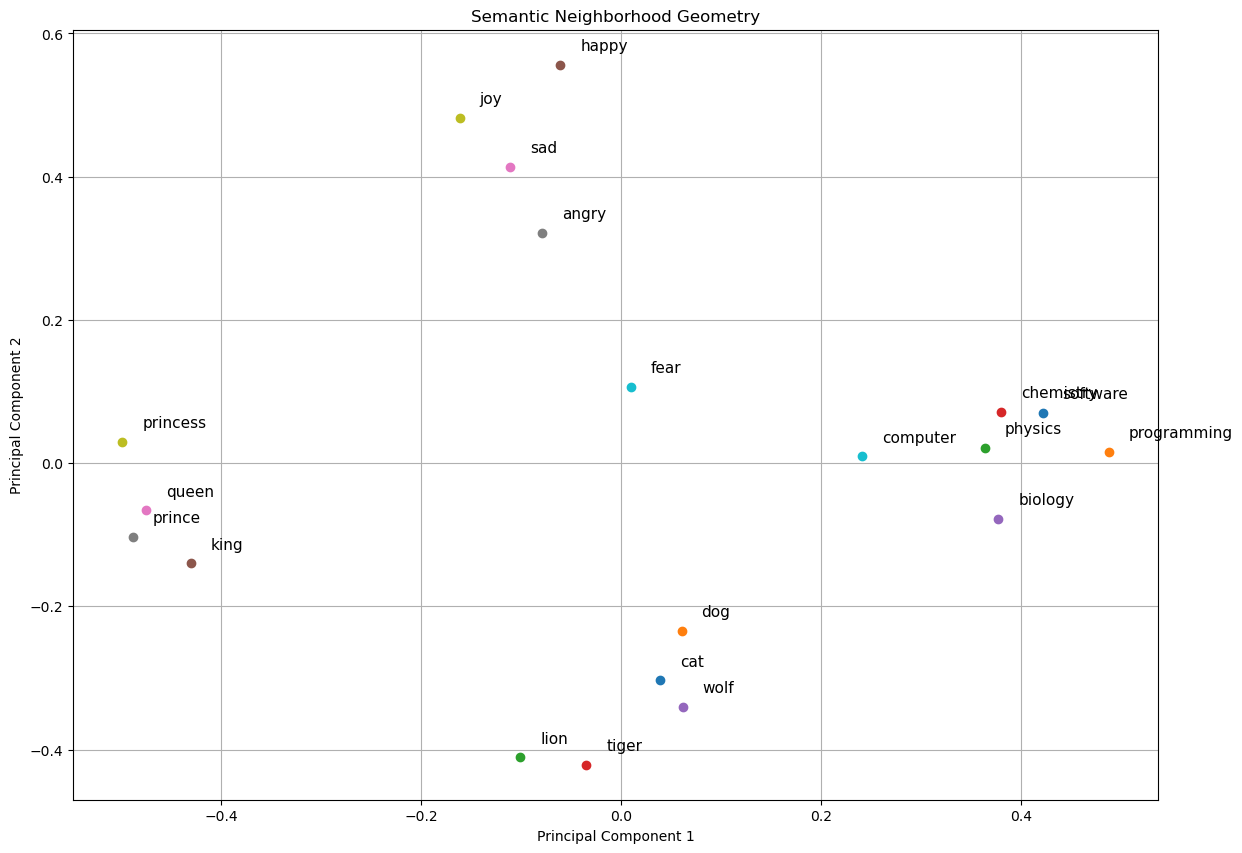

In [9]:

plt.figure(figsize=(14, 10))

for i, concept in enumerate(concepts):

    x = reduced_embeddings[i][0]
    y = reduced_embeddings[i][1]

    plt.scatter(x, y)

    plt.text(
        x + 0.02,
        y + 0.02,
        concept,
        fontsize=11
    )

plt.title("Semantic Neighborhood Geometry")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()



============================================================
8. INTERPRETATION
============================================================

OBSERVATION ANALYSIS
--------------------

Examine the visualization carefully.

Possible observations:

    • animals cluster together
    • royalty concepts cluster
    • sciences align nearby
    • emotions form neighborhoods

------------------------------------------------------------
IMPORTANT REALIZATION
------------------------------------------------------------

The model was NOT manually given:

    semantic categories.

Instead:

    structure emerged automatically
    during representation learning.

------------------------------------------------------------
LOCAL GEOMETRY
------------------------------------------------------------

Embedding spaces may possess:

    • local neighborhoods
    • semantic regions
    • cluster topology
    • relational continuity

------------------------------------------------------------
VERY IMPORTANT INSIGHT
------------------------------------------------------------

Modern retrieval systems work because:

    semantic meaning becomes searchable geometry.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Is semantic memory fundamentally:

    geometric organization?




============================================================
9. FAILURE CASES
============================================================

REAL SYSTEMS ARE IMPERFECT
--------------------------

Embedding neighborhoods possess limitations.

------------------------------------------------------------
LIMITATION 1 — CONTEXT AMBIGUITY
------------------------------------------------------------

Example:

    bank

could mean:

    • financial institution
    • river bank

Static embeddings struggle with ambiguity.

------------------------------------------------------------
LIMITATION 2 — DATASET BIAS
------------------------------------------------------------

Embeddings inherit patterns from training data.

This may introduce:

    • stereotypes
    • cultural imbalance
    • political bias

------------------------------------------------------------
LIMITATION 3 — HIGH-DIMENSIONAL DISTORTION
------------------------------------------------------------

Neighborhood relationships in 2D
may differ from true 384D geometry.

------------------------------------------------------------
LIMITATION 4 — SEMANTIC COMPLEXITY
------------------------------------------------------------

Human meaning may not perfectly map
into geometric proximity.

------------------------------------------------------------
THINK CRITICALLY
------------------------------------------------------------

Are semantic neighborhoods sufficient
to represent human understanding?




============================================================
10. SCIENTIFIC INSIGHT
============================================================

MOST IMPORTANT INSIGHT
----------------------

Modern AI systems organize meaning through:

    geometric neighborhood structure.

------------------------------------------------------------
EMBEDDING SPACES ENABLE
------------------------------------------------------------

    • semantic retrieval
    • recommendation systems
    • vector databases
    • semantic search
    • contextual routing
    • retrieval-augmented generation

------------------------------------------------------------
FOUNDATIONAL REALIZATION
------------------------------------------------------------

Meaning becomes:

    navigable geometric structure.

------------------------------------------------------------
IMPORTANT TRANSITION
------------------------------------------------------------

This step introduces a major idea:

    intelligence may partially operate
    through neighborhood traversal
    inside representation spaces.

------------------------------------------------------------
LOOK AHEAD
------------------------------------------------------------

Next steps investigate:

    • attention maps
    • contextual representation shifts
    • transformer interaction dynamics
    • latent manifolds
    • multimodal alignment

We are progressively uncovering:

    AI as dynamic representation geometry.




============================================================
11. EXPLORATION EXERCISES
============================================================

EXPLORATION 1
-------------

Add abstract concepts:

    • freedom
    • justice
    • intelligence
    • consciousness

Do abstract ideas form neighborhoods?

------------------------------------------------------------
EXPLORATION 2
-------------

Add political concepts:

    • democracy
    • socialism
    • capitalism

How does political geometry organize?

------------------------------------------------------------
EXPLORATION 3
-------------

Replace cosine similarity with:

    • Euclidean distance
    • Manhattan distance

Does neighborhood structure change?

------------------------------------------------------------
EXPLORATION 4
-------------

Replace PCA with:

    • t-SNE
    • UMAP

Which visualization preserves clusters better?

------------------------------------------------------------
EXPLORATION 5
-------------

Use sentence embeddings instead of words.

Example:

    "The cat slept."
    "The dog rested."

Do sentence neighborhoods emerge?

------------------------------------------------------------
FINAL QUESTION
------------------------------------------------------------

If semantic meaning becomes neighborhood structure...

then could cognition itself emerge through:

    navigation across representation manifolds?

============================================================

# IMPORTANT FUNCTIONS


# ------------------------------------------------------------
# PCA FOUNDATION
# ------------------------------------------------------------
#
# PCA:
#
#     Principal Component Analysis
#
# is a dimensionality reduction algorithm.
#
# ------------------------------------------------------------
# CORE OBJECTIVE
# ------------------------------------------------------------
#
# PCA attempts to discover:
#
#     the most important directions
#     inside high-dimensional data.
#
# These directions are called:
#
#     principal components.
#
# ------------------------------------------------------------
# INTUITION
# ------------------------------------------------------------
#
# Suppose embedding vectors occupy:
#
#     384-dimensional semantic space.
#
# Human beings cannot directly visualize:
#
#     384D geometry.
#
# PCA compresses this structure into:
#
#     lower-dimensional representations
#
# while attempting to preserve:
#
#     maximum variance structure.
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# PCA does NOT preserve:
#
#     exact geometry.
#
# Instead it preserves:
#
#     directions with strongest variation.
#
# ------------------------------------------------------------
# GEOMETRIC INTERPRETATION
# ------------------------------------------------------------
#
# Imagine a cloud of points.
#
# PCA finds:
#
#     the directions along which
#     the point cloud spreads most.
#
# These directions become:
#
#     principal axes.
#
# ============================================================
# STEP 1 — CENTER THE DATA
# ============================================================
#
# Given embedding matrix:
#
#     X ∈ R^(n × d)
#
# where:
#
#     n = number of samples
#     d = embedding dimensions
#
# Example:
#
#     X.shape = (1000, 384)
#
# PCA first centers the data:
#
#     X_centered = X - μ
#
# where:
#
#     μ = mean vector
#
# ------------------------------------------------------------
# WHY CENTER?
# ------------------------------------------------------------
#
# PCA studies:
#
#     variation around the mean.
#
# Without centering:
#
#     covariance estimation becomes distorted.
#
# ============================================================
# STEP 2 — COMPUTE COVARIANCE MATRIX
# ============================================================
#
# Covariance matrix:
#

:contentReference[oaicite:0]{index=0}

#
# where:
#
#     C ∈ R^(d × d)
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Covariance measures:
#
#     how dimensions vary together.
#
# Large covariance:
#
#     dimensions strongly correlated.
#
# Small covariance:
#
#     dimensions vary independently.
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# PCA studies:
#
#     global structure of variance.
#
# ============================================================
# STEP 3 — SOLVE EIGENVECTOR PROBLEM
# ============================================================
#
# PCA solves:
#

:contentReference[oaicite:1]{index=1}

#
# where:
#
#     C = covariance matrix
#     v = eigenvector
#     λ = eigenvalue
#
# ------------------------------------------------------------
# EIGENVECTORS
# ------------------------------------------------------------
#
# Eigenvectors represent:
#
#     principal directions of variation.
#
# ------------------------------------------------------------
# EIGENVALUES
# ------------------------------------------------------------
#
# Eigenvalues represent:
#
#     amount of variance captured
#     along each direction.
#
# Larger eigenvalue:
#
#     more important direction.
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# PCA ranks directions by:
#
#     information content.
#
# ============================================================
# STEP 4 — SELECT TOP COMPONENTS
# ============================================================
#
# Sort eigenvectors by:
#
#     descending eigenvalues.
#
# Select:
#
#     top-k eigenvectors.
#
# Example:
#
#     k = 2
#
# gives:
#
#     2D visualization space.
#
# ------------------------------------------------------------
# GEOMETRIC INTERPRETATION
# ------------------------------------------------------------
#
# We are choosing:
#
#     the most informative directions
#     inside semantic geometry.
#
# ============================================================
# STEP 5 — PROJECT DATA
# ============================================================
#
# Projection equation:
#



#
# where:
#
#     X   = original embedding matrix
#     V_k = top-k eigenvectors
#     Z   = reduced-dimensional representation
#
# ------------------------------------------------------------
# EXAMPLE
# ------------------------------------------------------------
#
# Original:
#
#     384-dimensional embeddings
#
# Projection:
#
#     2-dimensional visualization
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# PCA compresses geometry while attempting
# to preserve major variance structure.
#
# ============================================================
# FULL PCA ALGORITHM
# ============================================================
#
# INPUT:
#
#     High-dimensional embedding matrix X
#
# ------------------------------------------------------------
# ALGORITHM
# ------------------------------------------------------------
#
# Step 1:
#
#     Center data
#
#         X_centered = X - mean(X)
#
# Step 2:
#
#     Compute covariance matrix
#
#         C = (1/n) XᵀX
#
# Step 3:
#
#     Solve eigenvalue equation
#
#         Cv = λv
#
# Step 4:
#
#     Sort eigenvectors by eigenvalues
#
# Step 5:
#
#     Select top-k eigenvectors
#
#         V_k
#
# Step 6:
#
#     Project data
#
#         Z = XV_k
#
# OUTPUT:
#
#     Lower-dimensional representation
#
# ============================================================
# DEEP QUESTION
# ============================================================
#
# If semantic structure survives compression,
#
# does that imply:
#
#     language possesses lower-dimensional
#     latent organization?
#
# This question is deeply connected to:
#
#     • manifold learning
#     • latent representation theory
#     • semantic geometry
#     • modern AI systems
#

# ------------------------------------------------------------
# COVARIANCE MATRIX
# ------------------------------------------------------------
#
# The covariance matrix is one of the most important
# structures in PCA.
#
# It describes:
#
#     how dimensions vary together.
#
# ------------------------------------------------------------
# CORE IDEA
# ------------------------------------------------------------
#
# Suppose we have embeddings:
#
#     X ∈ R^(n × d)
#
# where:
#
#     n = number of samples
#     d = number of dimensions
#
# Example:
#
#     1000 embeddings
#     each with 384 dimensions
#
# Then:
#
#     X.shape = (1000, 384)
#
# ------------------------------------------------------------
# WHAT DOES EACH DIMENSION REPRESENT?
# ------------------------------------------------------------
#
# In embedding systems:
#
# each dimension may encode:
#
#     latent semantic properties
#
# although these properties are usually:
#
#     distributed and entangled.
#
# ------------------------------------------------------------
# IMPORTANT QUESTION
# ------------------------------------------------------------
#
# Do some dimensions behave similarly?
#
# Example:
#
# when one dimension increases,
# does another also increase?
#
# Covariance measures exactly this.
#
# ============================================================
# MATHEMATICAL FORMULATION
# ============================================================
#
# Covariance matrix:
#

:contentReference[oaicite:0]{index=0}

#
# where:
#
#     C ∈ R^(d × d)
#
# ------------------------------------------------------------
# MATRIX DIMENSIONS
# ------------------------------------------------------------
#
# If:
#
#     X.shape = (1000, 384)
#
# then:
#
#     C.shape = (384, 384)
#
# The covariance matrix measures:
#
#     relationships between ALL dimensions.
#
# ============================================================
# ELEMENT-WISE INTERPRETATION
# ============================================================
#
# Each matrix entry:
#
#     C(i,j)
#
# measures:
#
#     covariance between dimension i and j
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Large positive covariance:
#
#     dimensions increase together
#
# Large negative covariance:
#
#     one dimension increases
#     while the other decreases
#
# Near-zero covariance:
#
#     dimensions behave independently
#
# ============================================================
# INTUITION
# ============================================================
#
# Imagine two dimensions:
#
#     x-axis -> animal features
#     y-axis -> predator features
#
# If:
#
#     lion
#     tiger
#     wolf
#
# increase strongly in both dimensions,
#
# then covariance becomes:
#
#     strongly positive.
#
# ------------------------------------------------------------
# GEOMETRIC MEANING
# ------------------------------------------------------------
#
# Covariance reveals:
#
#     dominant directions of spread
#
# inside embedding space.
#
# PCA later uses this structure
# to identify:
#
#     principal directions of variation.
#
# ============================================================
# WHY PCA USES COVARIANCE
# ============================================================
#
# PCA wants to discover:
#
#     directions containing maximum information.
#
# Variance represents:
#
#     information spread.
#
# Covariance generalizes this idea across:
#
#     multiple dimensions simultaneously.
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# PCA is fundamentally studying:
#
#     how representation dimensions
#     co-evolve statistically.
#
# ============================================================
# SIMPLE NUMERICAL EXAMPLE
# ============================================================
#
# Suppose:
#
#     x = [1, 2, 3]
#     y = [2, 4, 6]
#
# As x increases:
#
#     y also increases.
#
# Therefore:
#
#     covariance(x, y) > 0
#
# ------------------------------------------------------------
# ANOTHER EXAMPLE
# ------------------------------------------------------------
#
# Suppose:
#
#     x = [1, 2, 3]
#     y = [6, 4, 2]
#
# As x increases:
#
#     y decreases.
#
# Therefore:
#
#     covariance(x, y) < 0
#
# ============================================================
# ALGORITHM FOR COVARIANCE MATRIX
# ============================================================
#
# INPUT:
#
#     Centered data matrix X
#
# ------------------------------------------------------------
# STEP 1
# ------------------------------------------------------------
#
# Compute transpose:
#
#     Xᵀ
#
# ------------------------------------------------------------
# STEP 2
# ------------------------------------------------------------
#
# Multiply:
#
#     XᵀX
#
# This computes:
#
#     pairwise dimension relationships.
#
# ------------------------------------------------------------
# STEP 3
# ------------------------------------------------------------
#
# Normalize:
#
#     divide by n
#
# giving:
#

:contentReference[oaicite:1]{index=1}

#
# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
#
# Covariance matrix:
#
#     C ∈ R^(d × d)
#
# containing:
#
#     global dimension interaction structure.
#
# ============================================================
# DEEP QUESTION
# ============================================================
#
# If embedding dimensions co-vary systematically,
#
# does this imply:
#
#     semantic structure is distributed
#     across coordinated latent dimensions?
#
# This question lies at the heart of:
#
#     • representation learning
#     • latent geometry
#     • manifold organization
#     • modern transformer systems
#